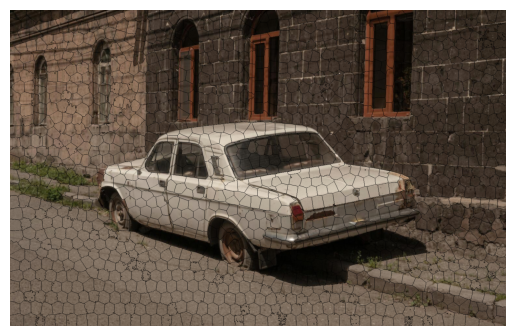

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm


# 读取图像
img = cv2.imread("../resources/data/car.jpg")

# 高斯模糊
img = cv2.GaussianBlur(img, (5, 5), 0)

# 转换到LAB颜色空间
lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

# 创建SLIC超像素对象
region_size = 32  # 超像素的大小
slic = cv2.ximgproc.createSuperpixelSLIC(
    lab_img, algorithm=cv2.ximgproc.SLICO, region_size=region_size
)

# 迭代分割
slic.iterate(10)

# 获取超像素标签和数量
sp_mask = slic.getLabelContourMask()  # 获取Mask，超像素边缘Mask==1
sp_labels = slic.getLabels()  # 获取超像素标签
sp_count = slic.getNumberOfSuperpixels()  # 获取超像素数目
mask_inv_slic = cv2.bitwise_not(sp_mask)
slic_img = cv2.bitwise_and(img, img, mask=mask_inv_slic)

# 可视化结果
plt.imshow(cv2.cvtColor(slic_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

- 获取SLIC超像素标签：首先，使用SLIC算法获得每个像素的超像素标签。

- 提取特征：为每个超像素提取特征，通常包括颜色特征（如平均颜色值）和空间特征（如超像素的中心坐标）。
  - 思路：每一个超像素取平均颜色，作为单个特征，最终组成了一个只有标签大小的特征图作为 K-Means 输入

- 构建特征矩阵：将所有超像素的特征组合成一个特征矩阵，作为K-Means聚类的输入。

- 执行K-Means聚类：使用OpenCV的cv2.kmeans函数对特征矩阵进行聚类。

- 生成聚类结果：根据K-Means的输出，将每个超像素分配到相应的聚类，并可视化结果。

In [2]:
feature_list = []

# 生成每一个 superpixel 的特征
for sp_lbl in tqdm(range(1, sp_count + 1)):
    mask = sp_labels == sp_lbl
    mask = mask.astype(np.uint8)
    # 颜色取均值
    mean_color = cv2.mean(img, mask=mask)[:3]
    feature_list.append([mean_color[0], mean_color[1], mean_color[2]])

features = np.array(feature_list, dtype=np.float32)

100%|██████████| 1425/1425 [00:03<00:00, 379.10it/s]


In [3]:
K = 10
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

_, kmeans_labels, kmeans_centers = cv2.kmeans(
    features, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS
)

clustered_image = np.zeros_like(img).reshape(-1, 3)
sp_labels = sp_labels.flatten()
kmeans_labels = kmeans_labels.flatten()
for sp_lbl in tqdm(range(1, sp_count + 1)):
    clustered_image[sp_labels == sp_lbl] = kmeans_centers[
        kmeans_labels[sp_lbl - 1]
    ].astype(int)

100%|██████████| 1425/1425 [00:03<00:00, 362.96it/s]


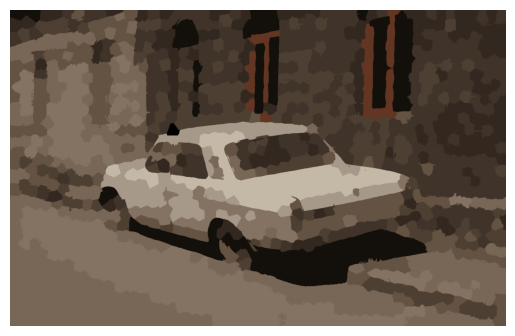

In [4]:
plt.imshow(cv2.cvtColor(clustered_image.reshape(img.shape), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()